In [1]:
import sys
from pathlib import Path

#local_path = Path("C:/Users/michi/Documents/Git/star_shadow")  # pas aan
#sys.path.insert(0, str(local_path))
import star_shadow as sts
print(sts.__file__)
import pandas as pd
import numpy as np

c:\Users\michi\miniconda3\envs\starshadow3\Lib\site-packages\star_shadow\__init__.py


In [ ]:
from pathlib import Path

base = Path("C:/Users/michi/Documents/Git/data")  # gebruik / hier
base.mkdir(parents=True, exist_ok=True)
print(base)

C:\Users\michi\Documents\Git\data


In [9]:
file = str(base) + '/stitched_excludedIntervals_spb1/lc_tic177162802_corrected_stitched.csv'

df = pd.read_csv(file)

times = np.array(df['time'])
flux = np.array(df['flux'])
flux_error = np.array(df['flux_err'])

In [10]:
file_name = "/Users/michi/Documents/Git/SPB-astroseismology/results_spb1.hdf5"
i_sectors = np.array([[0, len(times)]])
t_tot = np.ptp(times)  # total time base of observations
t_mean = np.mean(times)  # mean time of observations
t_mean_s = np.array([np.mean(times[s[0]:s[1]]) for s in i_sectors])  # mean time per observation sector
t_int = np.median(np.diff(times))  # integration time, taken to be the median time step
t_stats = [t_tot, t_mean, t_mean_s, t_int]

In [11]:
prewhitening = sts.iterative_prewhitening(times=times, signal=flux, signal_err=flux_error, i_sectors=i_sectors, t_stats=t_stats, file_name=file_name, data_id='testspb1', overwrite=True, verbose=True)

Looking for frequencies
N_f= 0, BIC= -3649035.72 (delta= N/A) - start extraction
N_f= 207, BIC= -3746016.00 (delta= 96980.28) - end extractionf= 4.001091, a= 0.0000210.00003625
Single frequencies removed: 4
N_f= 203, BIC= -3746010.28 (delta= 32.77)
Frequency sets replaced by a single frequency: 0 (0 frequencies). 
N_f= 203, BIC= -3746010.28 (delta= 0.00)
Number of frequencies passed criteria: 79 of 203. Candidate harmonics: 0, of which 0 passed.
Extraction of sinusoids complete.
203 frequencies, 611 free parameters, BIC: -3746010.29. Time taken: 2361.0s



In [12]:
print(prewhitening)

(array([-2.62317343e-05]), array([-2.9355992e-09]), array([1.07820347e+00, 8.86402115e-01, 1.54218139e+00, 1.13939542e+00,
       1.08583511e-01, 1.47997889e+00, 9.82092944e-01, 1.18680672e+00,
       9.44818580e-01, 1.33329111e+00, 1.19260131e+00, 7.35277120e-01,
       4.94645608e-01, 8.62159700e-01, 1.61233541e+00, 1.23473372e-01,
       1.54309402e+00, 7.88262530e-01, 1.68874471e+00, 7.06864268e-01,
       1.38134409e-01, 1.52478205e-01, 1.28669379e+00, 1.67640530e+00,
       9.45580946e-02, 8.38352543e-01, 3.19021102e+00, 1.55423315e-01,
       1.41651009e-01, 1.49125956e+00, 6.43625808e-01, 9.44274791e-01,
       8.62949009e-01, 1.90544915e-01, 8.86695450e-01, 1.28271726e+00,
       1.90348840e+00, 6.35060665e-01, 1.17278016e+00, 1.79502556e-01,
       8.20297096e-01, 2.07881255e-01, 1.18492755e-01, 3.55397817e-02,
       2.94071306e+00, 1.46663122e-01, 7.35747669e-01, 7.49879338e-01,
       7.06437358e-01, 2.84062411e+00, 1.22474858e+00, 7.67823978e-01,
       1.27057746e+00, 7.

In [16]:
import h5py
itprw = h5py.File(file_name)
list(itprw.keys())

['a_n',
 'a_n_err',
 'a_n_hdi',
 'c_err',
 'c_hdi',
 'const',
 'cosi',
 'depth_1',
 'depth_2',
 'e',
 'ecosw',
 'esinw',
 'f_n',
 'f_n_err',
 'f_n_hdi',
 'i',
 'i_sectors',
 'log_rr',
 'log_sb',
 'p_orb',
 'passed_b',
 'passed_h',
 'passed_sigma',
 'passed_snr',
 'ph_n',
 'ph_n_err',
 'ph_n_hdi',
 'phi_0',
 'r_rat',
 'r_sum',
 'ratios_1',
 'ratios_2',
 'ratios_3',
 'ratios_4',
 'sb_rat',
 'sl_err',
 'sl_hdi',
 'slope',
 't_1',
 't_1_1',
 't_1_2',
 't_2',
 't_2_1',
 't_2_2',
 't_b_1_1',
 't_b_1_2',
 't_b_2_1',
 't_b_2_2',
 't_zero',
 'w']

(0.0, 12.0)

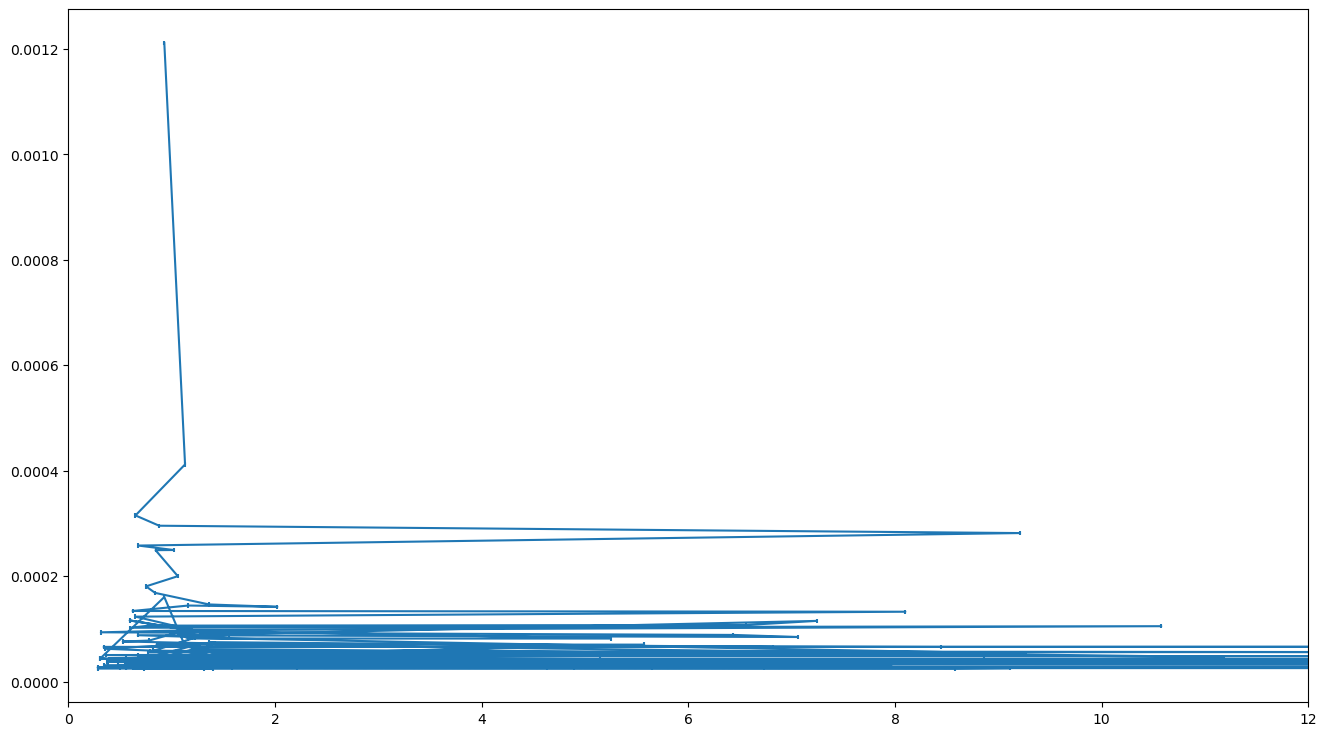

In [21]:
import matplotlib.pyplot as plt

amps = np.array(itprw['a_n'])
freq = np.array(itprw['f_n'])
err = np.array(itprw['a_n_err'])
periods = 1/ freq

plt.errorbar(periods, amps, yerr=err)
plt.xlim(0,12)